---
format:
  html:
    other-links:
      - text: This notebook
        href: A8.ipynb
---

# A9

- Complete the following and submit to Canvas before Nov 14 11:59PM,
- Late work will recieve 0%,
- Each assignment is worth the same, 
- Please get in contact with the instructor in plenty of time if you need help,
- Before submitting your work, make sure to check everything runs as expected. Click **Kernel > Restart Kernel and Run All Cells**.
- Feel free to add more cells to experiment or test your answers,
- I encourage you to discuss the course material and assignment questions with your classmates. You may complete this assignment in groups of at most 2 - please clearly state who you are working with,
- The use of GenAI is prohibited as outlined in the course syllabus. If I suspect you of cheating, you may be asked to complete a written or oral exam on the content of this assignment. 

In [1]:
# | code-fold: true

using Plots
using LaTeXStrings
using Polynomials
using LinearAlgebra

"""
    ChebyshevNodes( n; type=2) 

Returns the ``n+1`` Chebyshev nodes ``X = \\{x_0, ..., x_n\\}`` of type type (default being type II) 
"""
function ChebyshevNodes( n; type=2) 
    if (type == 1)
        return @. cos( (2*(n:-1:0)+1)*pi/(2*(n+1)) )
    else
        return @. cos( (pi/n)*(n:-1:0) )
    end
end

"""
    ChebyshevInterpolant( f, n ) 

Returns the polynomial of degree ``n`` interpolating ``f`` at Chebyshev nodes using the Barycentric formula
"""
function ChebyshevInterpolant( f, n ) 
    x = ChebyshevNodes(n)
    y = f.(x)

    λ = zeros(n+1)
    λ[1] = 1/2
    λ[n+1] = (-1)^n/2
    for j in 1:(n-1)
        λ[j+1] = (-1)^j
    end

    return t -> t in x ? f(t) : sum( @. λ * y / (t - x) ) / sum( @. λ / (t - x) )
end

"""
    Lagrange( f, n ) 

"""
function Lagrange( i, n ) 
    x = ChebyshevNodes(n)
    y = [ j==i ? 1 : 0 for j=0:n ]

    return fit( ChebyshevT, x, y )
end;

## A: Vandermonde matrix

For distinct points $X = \{ x_0, \dots, x_n \}$ and a function values $y_j := f(x_j)$, consider the *Lagrange interpolation problem*: find $p(x) = a_0 + a_1 x + a_2 x^2 + \dots + a_n x^n$ such that $p(x_j) = y_j$ for $j=0,\dots,n$. 

1. Show that the solution can be written as the matrix equation

\begin{align}
    V \bm a 
    %
    := 
    \begin{pmatrix}
        1 & x_0 & x_0^2 & \cdots & x_0^n \\
         1 & x_1 & x_1^2 & \cdots & x_1^n \\
          1 & x_2 & x_2^2 & \cdots & x_2^n \\
          \vdots & \vdots & \vdots &\ddots & \vdots \\
           1 & x_n & x_n^2 & \cdots & x_n^n
    \end{pmatrix}
    \begin{pmatrix}
        a_0 \\ a_1 \\ a_2 \\ \vdots \\ a_n
    \end{pmatrix}
    %
    = \begin{pmatrix}
        y_0 \\ y_1 \\ y_2 \\ \vdots \\ y_n
    \end{pmatrix},
\end{align}

where the matrix $V$ is known as the *Vandermonde matrix*. 

<div class='alert alert-block alert-success'><b>Answer.</b> 

[your answer here]

</div> 

2. Explain why $V$ is invertible.

<div class='alert alert-block alert-success'><b>Answer.</b> 



</div> 

Equivalently, we can choose a different *basis* and expand $p$ as a polynomial in this basis. In the following, we will choose Chebyshev polynomials $T_k(x)$ and write $p(x) = b_0 T_0(x) + b_1 T_1(x) + \dots + b_n T_n(x)$. Now we wish to find the coefficients $(b_i)$ so that $p$ satisfies $p(x_j) = y_j$ for $j=0,\dots,n$.

3. Write down a matrix equation for the coefficients $(b_i)_{i=0}^n$.

In [ ]:
n = 10;
mesh = -1:.001:1

f = x->1/(1 + exp(10 * x))
X = ChebyshevNodes( n )
Y = f.(X)
V = X.^(0:n)'

# Barycentric formula
q = ChebyshevInterpolant( f, n ) 

# Vandermonde
p = Polynomial( V \ Y )

println("max|p(x)-f(x)| = ", maximum( x-> abs(p(x)-f(x)), mesh ) )
println("max|q(x)-f(x)| = ", maximum( x-> abs(q(x)-f(x)), mesh ) )

plot( f, -1, 1, label="f", linestyle=:dash)
plot!( p, -1, 1, label="q = Barycentric formula")
plot!( q, -1, 1, label="p = Vandermonde" )


In the following cell we compute the polynomial interpolant $q$ by using the Barycentric formula (included in the code above) and $p$ by solving the linear system $V \bm a = \bm y$ where $y_j := f(x_j)$ for $j = 0,\dots,n$. 

max|p(x)-f(x)| = 0.04522292784077575
max|q(x)-f(x)| = 0.04522292784077531


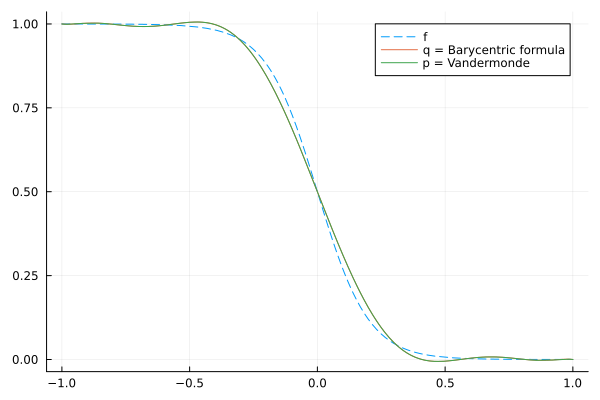

In [2]:
n = 10;
mesh = -1:.001:1

f = x->1/(1 + exp(10 * x))
X = ChebyshevNodes( n )
Y = f.(X)
V = X.^(0:n)'

# Barycentric formula
q = ChebyshevInterpolant( f, n ) 

# Vandermonde
p = Polynomial( V \ Y )

println("max|p(x)-f(x)| = ", maximum( x-> abs(p(x)-f(x)), mesh ) )
println("max|q(x)-f(x)| = ", maximum( x-> abs(q(x)-f(x)), mesh ) )

plot( f, -1, 1, label="f", linestyle=:dash)
plot!( p, -1, 1, label="q = Barycentric formula")
plot!( q, -1, 1, label="p = Vandermonde" )


3. Plot the errors $\| p - f \|_{L^\infty([-1,1])} := \max_{x \in [-1,1]} |p(x) - f(x)|$ and $\| q - f \|_{L^\infty([-1,1])}$ as a function of $n$. Some of the code has been provided for you.

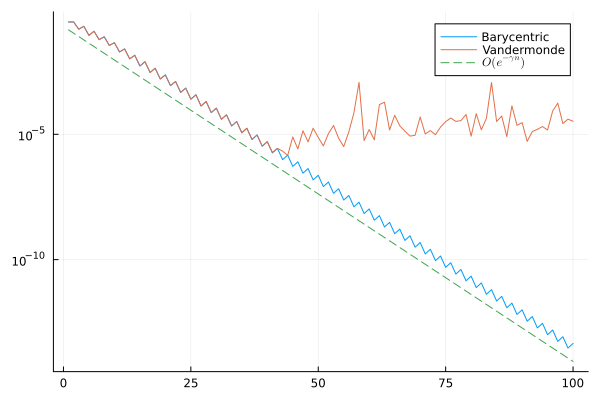

In [3]:
N = 100;

mesh = -1:.001:1
errp = zeros(N)
errq = zeros(N)
cond_numbers = zeros(N)

for n = 1:N
    X = ChebyshevNodes( n )
    Y = f.(X)
    V = X.^(0:n)'

    # Barycentric formula
    q = ChebyshevInterpolant( f, n ) 

    # Vandermonde
    p = Polynomial( V \ Y )

    # (Approximate) the errors 
    errp[n] = maximum( x-> abs(p(x)-f(x)), mesh ) 
    errq[n] = maximum( x-> abs(q(x)-f(x)), mesh ) 

    # condition numbers 
    cond_numbers[n] = cond(V)
end

# Your code here!

plot( 1:N, errq, yaxis=:log, label="Barycentric")
plot!( 1:N, errp, yaxis=:log, label="Vandermonde")
plot!( 1:N, (1/5)*exp.(-(1:N)/3.25), yaxis=:log, linestyle=:dash, label=L"O(e^{- \gamma \, n})")

4. Which method (Barycentric formula vs solving a linear system involving the Vandermonde matrix) would you use in practice and why?

<div class='alert alert-block alert-success'><b>Answer.</b> 


</div> 